In [42]:
import pandas as pd

In [43]:
        messages = pd.read_csv('SMSSpamCollection.txt', sep='\t', names=['label', 'message'])
        messages

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [44]:
messages.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [45]:
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

In [46]:
def cleaning(message):
    m = re.sub('[^a-zA-Z]', ' ', message)
    m = m.lower()
    m = m.split()
    m = [ps.stem(word) for word in m if not word in stopwords.words('english')]
    m = ' '.join(m)
    return m

In [47]:
m = "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
cleaning(m)

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [48]:
messages['message_cleaning'] = messages['message'].apply(cleaning)
messages.head()

,label,message,message_cleaning
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [49]:
messages.shape

(5572, 3)

In [50]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=2500, ngram_range=(1,2))

In [51]:
X = cv.fit_transform(messages['message_cleaning']).toarray()
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5572, 2500))

In [52]:
cv.vocabulary_

{'go': np.int64(795),
 'point': np.int64(1607),
 'crazi': np.int64(456),
 'avail': np.int64(114),
 'bugi': np.int64(225),
 'great': np.int64(852),
 'world': np.int64(2429),
 'la': np.int64(1103),
 'cine': np.int64(352),
 'got': np.int64(840),
 'wat': np.int64(2337),
 'ok': np.int64(1481),
 'lar': np.int64(1114),
 'joke': np.int64(1071),
 'wif': np.int64(2395),
 'free': np.int64(709),
 'entri': np.int64(612),
 'wkli': np.int64(2419),
 'comp': np.int64(406),
 'win': np.int64(2400),
 'cup': np.int64(471),
 'final': np.int64(677),
 'st': np.int64(1979),
 'may': np.int64(1269),
 'text': np.int64(2083),
 'receiv': np.int64(1704),
 'question': np.int64(1665),
 'std': np.int64(1992),
 'txt': np.int64(2196),
 'rate': np.int64(1682),
 'appli': np.int64(78),
 'free entri': np.int64(714),
 'entri wkli': np.int64(614),
 'std txt': np.int64(1993),
 'txt rate': np.int64(2202),
 'rate appli': np.int64(1684),
 'dun': np.int64(573),
 'say': np.int64(1803),
 'earli': np.int64(579),
 'alreadi': np.int64(5

In [53]:
y = pd.get_dummies(messages['label'])
y

,ham,spam
0,True,False
1,True,False
2,False,True
3,True,False
4,True,False
...,...,...
5567,False,True
5568,True,False
5569,True,False
5570,True,False


In [54]:
y = y.iloc[:, 0].values
y

array([ True,  True, False, ...,  True,  True,  True], shape=(5572,))

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

In [56]:
from sklearn.naive_bayes import MultinomialNB

spam_model = MultinomialNB()
spam_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [57]:
y_pred = spam_model.predict(X_test)
y_pred

array([ True,  True,  True, ...,  True,  True,  True], shape=(1115,))

In [58]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9856502242152466

In [59]:
y_pred_train = spam_model.predict(X_train)

In [60]:
accuracy_score(y_train, y_pred_train)

0.9874354947273951

In [61]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.96      0.93      0.95       149
        True       0.99      0.99      0.99       966

    accuracy                           0.99      1115
   macro avg       0.97      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[139  10]
 [  6 960]]


In [63]:
import matplotlib.pyplot as plt

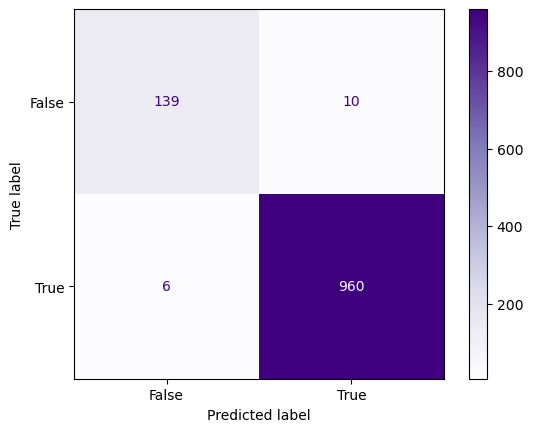

In [64]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
    display_labels=spam_model.classes_)

disp.plot(cmap="Purples")
plt.show()